# Qwen3-VL-32B


# Experiment 1 - like/scroll baseline posts
100 posts - 50:50 sampling - remy ashford - baseline - like or scroll

In [2]:
# This installs torch 2.6.0 and torchvision 0.21.0 pinned to cu124 because the
# GPU server's NVIDIA driver supports CUDA 12.4 but not CUDA 13.0. torchaudio is
# explicitly uninstalled and excluded because it is not needed for Qwen3-VL and
# its cu124 build conflicts with the server's CUDA 13 runtime libraries, causing
# an OSError on import. transformers is installed from source because Qwen3-VL
# support is not yet available in a stable PyPI release.

import sys, subprocess

# Uninstall torchaudio if it exists from a previous session
subprocess.run([sys.executable, "-m", "pip", "uninstall", "torchaudio", "-y"])

# Install torch stack (no torchaudio)
subprocess.run([sys.executable, "-m", "pip", "install",
    "torch==2.6.0", "torchvision==0.21.0",
    "--index-url", "https://download.pytorch.org/whl/cu124",
    "--user", "-q"], check=True)

# Install transformers + dependencies
subprocess.run([sys.executable, "-m", "pip", "install",
    "git+https://github.com/huggingface/transformers",
    "accelerate", "qwen-vl-utils",
    "--user", "-q"], check=True)

print("✅ Done — restart the kernel now")

✅ Done — restart the kernel now


Restart kernel after running above cell

In [1]:
!nvidia-smi

Sun Jun 14 17:46:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.127.08             Driver Version: 550.127.08     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:AF:00.0 Off |                    0 |
| N/A   34C    P0             81W /  700W |       1MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
import sys
sys.path.append("/home/jovyan")

from config_hf_token import HF_TOKEN
from huggingface_hub import login

login(token=HF_TOKEN)

In [5]:
import torch
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

processor = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-32B-Instruct")

model = Qwen3VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen3-VL-32B-Instruct", # changed from 8b to 32b
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

print("✅ Loaded successfully")

Using device: cuda


Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1058 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

✅ Loaded successfully


'\nimport torch\nfrom transformers import AutoModelForImageTextToText, AutoProcessor\nimport os\n\ndevice = "cuda" if torch.cuda.is_available() else "cpu"\nprint(f"Using device: {device}")\n\nprocessor = AutoProcessor.from_pretrained(\n    "Qwen/Qwen3-VL-8B-Instruct",\n    trust_remote_code=True,\n)\n\nmodel = AutoModelForImageTextToText.from_pretrained(\n    "Qwen/Qwen3-VL-8B-Instruct",\n    dtype=torch.bfloat16,\n    device_map="auto",\n    trust_remote_code=True\n)\n\nprint("✅ Loaded successfully")\n'

In [3]:
print(torch.cuda.get_device_name(0))
print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"VRAM free: {torch.cuda.memory_reserved(0) / 1e9:.1f} GB reserved")

NVIDIA H100 80GB HBM3
VRAM total: 84.9 GB
VRAM free: 0.0 GB reserved


In [6]:
import sys
from pathlib import Path

ROOT_DIR = Path().resolve().parents[2]          # project root
sys.path.append(str(ROOT_DIR / "experiments"))  # so we can import experiments/utils/

# 1) Baseline - Gender neutral user

## Creating the paired sample

In [7]:
from utils.sampling import build_paired_sample

# --- Configuration ---
EXPERIMENT_DIR = Path().resolve().parent        # experiments/e1/
OUTPUT_DIR = Path().resolve() / "outputs"       # experiments/e1/qwen3-8b-vl/outputs/
SEED = 42
SAMPLE_SIZE = 50

# --- Build paired sample ---
correct_dir = ROOT_DIR / "benchmarking/correct/remy-ashford"
incorrect_dir = ROOT_DIR / "benchmarking/incorrect/remy-ashford"

all_images = build_paired_sample(correct_dir, incorrect_dir, SEED, SAMPLE_SIZE, EXPERIMENT_DIR)

📋 Loading existing selection from /home/jovyan/experiments/e1/selected_images.json
✅ All selected numbers verified in both correct and incorrect folders.
Selected 50 pairs → 100 images total


In [8]:
import importlib
import utils.e1_optimized as e1_optimized_module
importlib.reload(e1_optimized_module)

from utils.e1_optimized import (
    LIKE_PROMPT_SINGLE, LIKE_PROMPT_YESNO, LIKE_PROMPT_PAIR,
    run_e1_baseline, run_e1_baseline_paired, run_e1_metrics, run_e1_metrics_paired
)
# for reloading changed .py file
import importlib
import utils.e1_analysis_optimized as e1_analysis_module
importlib.reload(e1_analysis_module)

from utils.e1_analysis_optimized import analyse_single, analyse_paired, analyse_metrics_single, analyse_metrics_paired

OUTPUT_DIR = Path().resolve() / "outputs"

## Approach 1: like or scroll - single image

In [9]:
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_baseline.json")

✅ 001_correct → scroll
✅ 001_incorrect → scroll
✅ 003_correct → scroll
✅ 003_incorrect → scroll
✅ 004_correct → scroll
✅ 004_incorrect → scroll
✅ 005_correct → scroll
✅ 005_incorrect → scroll
✅ 006_correct → like
✅ 006_incorrect → scroll
✅ 007_correct → scroll
✅ 007_incorrect → scroll
✅ 012_correct → scroll
✅ 012_incorrect → scroll
✅ 014_correct → like
✅ 014_incorrect → scroll
✅ 015_correct → scroll
✅ 015_incorrect → scroll
✅ 017_correct → scroll
✅ 017_incorrect → scroll
✅ 018_correct → scroll
✅ 018_incorrect → scroll
✅ 020_correct → like
✅ 020_incorrect → scroll
✅ 021_correct → like
✅ 021_incorrect → scroll
✅ 023_correct → scroll
✅ 023_incorrect → scroll
✅ 025_correct → scroll
✅ 025_incorrect → scroll
✅ 026_correct → scroll
✅ 026_incorrect → scroll
✅ 028_correct → scroll
✅ 028_incorrect → scroll
✅ 029_correct → scroll
✅ 029_incorrect → scroll
✅ 030_correct → like
✅ 030_incorrect → scroll
✅ 032_correct → like
✅ 032_incorrect → scroll
✅ 036_correct → scroll
✅ 036_incorrect → scroll
✅ 03

In [10]:
# Approach 1
# single like/scroll
analyse_single(OUTPUT_DIR, "e1_results_baseline.json", like_answer="like")



Single image analysis: e1_results_baseline
=== Summary ===


,metric,value
0,overall_like_rate_%,18.0
1,like_rate_correct_%,32.0
2,like_rate_incorrect_%,4.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,scroll
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
2,003_correct,correct,You are shown a social media post.\nYou can ei...,scroll
3,003_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
4,004_correct,correct,You are shown a social media post.\nYou can ei...,scroll
...,...,...,...,...
95,096_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
96,098_correct,correct,You are shown a social media post.\nYou can ei...,scroll
97,098_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
98,100_correct,correct,You are shown a social media post.\nYou can ei...,scroll


✅ Saved to: /home/jovyan/experiments/e1/qwen3-vl-32b/outputs/e1_analysis_baseline.csv


## Approach 1: YES/NO variant

In [11]:
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_baseline_yesno.json")


✅ 001_correct → no
✅ 001_incorrect → no
✅ 003_correct → no
✅ 003_incorrect → no
✅ 004_correct → no
✅ 004_incorrect → no
✅ 005_correct → no
✅ 005_incorrect → no
✅ 006_correct → yes
✅ 006_incorrect → no
✅ 007_correct → no
✅ 007_incorrect → no
✅ 012_correct → no
✅ 012_incorrect → no
✅ 014_correct → yes
✅ 014_incorrect → no
✅ 015_correct → no
✅ 015_incorrect → no
✅ 017_correct → no
✅ 017_incorrect → no
✅ 018_correct → no
✅ 018_incorrect → no
✅ 020_correct → no
✅ 020_incorrect → no
✅ 021_correct → no
✅ 021_incorrect → no
✅ 023_correct → no
✅ 023_incorrect → no
✅ 025_correct → no
✅ 025_incorrect → no
✅ 026_correct → no
✅ 026_incorrect → no
✅ 028_correct → no
✅ 028_incorrect → no
✅ 029_correct → no
✅ 029_incorrect → no
✅ 030_correct → yes
✅ 030_incorrect → no
✅ 032_correct → yes
✅ 032_incorrect → no
✅ 036_correct → no
✅ 036_incorrect → no
✅ 039_correct → no
✅ 039_incorrect → no
✅ 044_correct → no
✅ 044_incorrect → no
✅ 047_correct → no
✅ 047_incorrect → no
✅ 052_correct → no
✅ 052_incorrect →

In [12]:
analyse_single(OUTPUT_DIR, "e1_results_baseline_yesno.json", like_answer="yes")


Single image analysis: e1_results_baseline_yesno
=== Summary ===


,metric,value
0,overall_yes_rate_%,12.0
1,yes_rate_correct_%,24.0
2,yes_rate_incorrect_%,0.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,no
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
2,003_correct,correct,You are shown a social media post.\nYou can ei...,no
3,003_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
4,004_correct,correct,You are shown a social media post.\nYou can ei...,no
...,...,...,...,...
95,096_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
96,098_correct,correct,You are shown a social media post.\nYou can ei...,no
97,098_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
98,100_correct,correct,You are shown a social media post.\nYou can ei...,no


✅ Saved to: /home/jovyan/experiments/e1/qwen3-vl-32b/outputs/e1_analysis_baseline_yesno.csv


## Approach 2: A/B testing - paired images

In [13]:
print(f"\n{'='*60}\nApproach 2: paired A/B\n{'='*60}")
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]
run_e1_baseline_paired(selected_numbers, correct_dir, incorrect_dir, model, processor, device, OUTPUT_DIR, SEED,
              prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_baseline_paired.json")




Approach 2: paired A/B
✅ Pair 001 → liked correct (answered A)
✅ Pair 003 → liked correct (answered A)
✅ Pair 004 → liked correct (answered B)
✅ Pair 005 → liked correct (answered A)
✅ Pair 006 → liked correct (answered B)
✅ Pair 007 → liked correct (answered A)
✅ Pair 012 → liked correct (answered B)
✅ Pair 014 → liked incorrect (answered A)
✅ Pair 015 → liked correct (answered A)
✅ Pair 017 → liked correct (answered A)
✅ Pair 018 → liked correct (answered A)
✅ Pair 020 → liked correct (answered B)
✅ Pair 021 → liked correct (answered A)
✅ Pair 023 → liked correct (answered A)
✅ Pair 025 → liked correct (answered A)
✅ Pair 026 → liked correct (answered B)
✅ Pair 028 → liked incorrect (answered A)
✅ Pair 029 → liked correct (answered A)
✅ Pair 030 → liked correct (answered A)
✅ Pair 032 → liked correct (answered B)
✅ Pair 036 → liked correct (answered B)
✅ Pair 039 → liked correct (answered B)
✅ Pair 044 → liked incorrect (answered A)
✅ Pair 047 → liked correct (answered A)
✅ Pair 052

In [14]:
analyse_paired(OUTPUT_DIR, "e1_results_baseline_paired.json")


Paired A/B analysis: e1_results_baseline_paired
=== Summary ===


,metric,value
0,liked_correct_%,80.0
1,liked_incorrect_%,20.0
2,invalid_answer_%,0.0


=== Per Pair Results ===


,num,post_a_variant,post_b_variant,prompt,answer,liked_variant
0,001,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
1,003,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
2,004,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct
3,005,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
4,006,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct
5,007,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
6,012,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct
7,014,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
8,015,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
9,017,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct


✅ Saved to: /home/jovyan/experiments/e1/qwen3-vl-32b/outputs/e1_analysis_baseline_paired.csv


# Likes only - Gender neutral user

In [15]:
"""
import os
os.chdir('/home/jovyan/benchmarking')
!unzip correct/remy-ashford/correct_likes_only.zip -d correct/remy-ashford/metrics/likes_only
!unzip incorrect/remy-ashford/incorrect_likes_only.zip -d incorrect/remy-ashford/metrics/likes_only
"""

"\nimport os\nos.chdir('/home/jovyan/benchmarking')\n!unzip correct/remy-ashford/correct_likes_only.zip -d correct/remy-ashford/metrics/likes_only\n!unzip incorrect/remy-ashford/incorrect_likes_only.zip -d incorrect/remy-ashford/metrics/likes_only\n"

## Approach 1: like or scroll - single image

In [16]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_likes_only.json")


✅ 001_correct_10 → like
✅ 001_incorrect_10 → scroll
✅ 003_correct_10 → like
✅ 003_incorrect_10 → scroll
✅ 004_correct_10 → like
✅ 004_incorrect_10 → scroll
✅ 005_correct_10 → like
✅ 005_incorrect_10 → scroll
✅ 006_correct_10 → like
✅ 006_incorrect_10 → scroll
✅ 007_correct_10 → like
✅ 007_incorrect_10 → scroll
✅ 012_correct_10 → like
✅ 012_incorrect_10 → scroll
✅ 014_correct_10 → like
✅ 014_incorrect_10 → like
✅ 015_correct_10 → like
✅ 015_incorrect_10 → like
✅ 017_correct_10 → like
✅ 017_incorrect_10 → like
✅ 018_correct_10 → like
✅ 018_incorrect_10 → scroll
✅ 020_correct_10 → like
✅ 020_incorrect_10 → scroll
✅ 021_correct_10 → like
✅ 021_incorrect_10 → scroll
✅ 023_correct_10 → like
✅ 023_incorrect_10 → like
✅ 025_correct_10 → like
✅ 025_incorrect_10 → like
✅ 026_correct_10 → like
✅ 026_incorrect_10 → like
✅ 028_correct_10 → like
✅ 028_incorrect_10 → scroll
✅ 029_correct_10 → like
✅ 029_incorrect_10 → scroll
✅ 030_correct_10 → like
✅ 030_incorrect_10 → scroll
✅ 032_correct_10 → like


In [17]:
# metrics like/scroll
analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only.json", like_answer="like")


Metrics single image analysis: e1_results_likes_only
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,66.83
1,like_rate_correct_%,100.00
2,like_rate_incorrect_%,33.67


=== Rate per Scale Value ===


/home/jovyan/experiments/utils/e1_analysis_optimized.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,100.0,59.0,100.0,18.0
1,100,100.0,69.0,100.0,38.0
2,1000,100.0,68.0,100.0,36.0
3,10000,100.0,70.0,100.0,40.0
4,100000,100.0,66.0,100.0,32.0
5,1000000,100.0,69.0,100.0,38.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,like
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,like
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,like
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,like
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll


✅ Saved to: /home/jovyan/experiments/e1/qwen3-vl-32b/outputs/e1_analysis_likes_only.csv


## Approach 1: YES/NO variant

In [18]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_likes_only_yesno.json")


✅ 001_correct_10 → yes
✅ 001_incorrect_10 → no
✅ 003_correct_10 → yes
✅ 003_incorrect_10 → no
✅ 004_correct_10 → yes
✅ 004_incorrect_10 → no
✅ 005_correct_10 → yes
✅ 005_incorrect_10 → no
✅ 006_correct_10 → yes
✅ 006_incorrect_10 → no
✅ 007_correct_10 → yes
✅ 007_incorrect_10 → no
✅ 012_correct_10 → yes
✅ 012_incorrect_10 → no
✅ 014_correct_10 → yes
✅ 014_incorrect_10 → yes
✅ 015_correct_10 → yes
✅ 015_incorrect_10 → yes
✅ 017_correct_10 → yes
✅ 017_incorrect_10 → yes
✅ 018_correct_10 → yes
✅ 018_incorrect_10 → no
✅ 020_correct_10 → yes
✅ 020_incorrect_10 → no
✅ 021_correct_10 → yes
✅ 021_incorrect_10 → no
✅ 023_correct_10 → yes
✅ 023_incorrect_10 → yes
✅ 025_correct_10 → yes
✅ 025_incorrect_10 → yes
✅ 026_correct_10 → yes
✅ 026_incorrect_10 → no
✅ 028_correct_10 → yes
✅ 028_incorrect_10 → no
✅ 029_correct_10 → yes
✅ 029_incorrect_10 → no
✅ 030_correct_10 → yes
✅ 030_incorrect_10 → no
✅ 032_correct_10 → yes
✅ 032_incorrect_10 → no
✅ 036_correct_10 → yes
✅ 036_incorrect_10 → no
✅ 039_co

In [19]:
# metrics yes/no
analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only_yesno.json", like_answer="yes")


Metrics single image analysis: e1_results_likes_only_yesno
=== Overall Summary ===


,metric,value
0,overall_yes_rate_%,63.0
1,yes_rate_correct_%,100.0
2,yes_rate_incorrect_%,26.0


=== Rate per Scale Value ===


/home/jovyan/experiments/utils/e1_analysis_optimized.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_yes_rate_%,yes_rate_correct_%,yes_rate_incorrect_%
0,10,100.0,58.0,100.0,16.0
1,100,100.0,65.0,100.0,30.0
2,1000,100.0,62.0,100.0,24.0
3,10000,100.0,67.0,100.0,34.0
4,100000,100.0,63.0,100.0,26.0
5,1000000,100.0,63.0,100.0,26.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,yes
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,yes
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,yes
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,yes
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,yes
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,no


✅ Saved to: /home/jovyan/experiments/e1/qwen3-vl-32b/outputs/e1_analysis_likes_only_yesno.csv


## Approach 2: A/B testing - paired images

In [20]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_paired.json",
                      baseline_correct_dir=correct_dir,
                      baseline_incorrect_dir=incorrect_base / "10")

✅ 001_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 003_correct0_vs_incorrect10 → liked correct (answered A)
✅ 004_correct0_vs_incorrect10 → liked correct (answered B)
✅ 005_correct0_vs_incorrect10 → liked correct (answered A)
✅ 006_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 007_correct0_vs_incorrect10 → liked correct (answered A)
✅ 012_correct0_vs_incorrect10 → liked correct (answered A)
✅ 014_correct0_vs_incorrect10 → liked correct (answered A)
✅ 015_correct0_vs_incorrect10 → liked incorrect (answered B)
✅ 017_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 018_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 020_correct0_vs_incorrect10 → liked correct (answered A)
✅ 021_correct0_vs_incorrect10 → liked correct (answered A)
✅ 023_correct0_vs_incorrect10 → liked correct (answered A)
✅ 025_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 026_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 028_correct0_vs_incorrect10 → liked corr

In [21]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_likes_only_paired.json")


Metrics paired A/B analysis: e1_results_likes_only_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,74.0
1,overall_liked_incorrect_%,26.0
2,invalid_answer_%,0.0


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/experiments/utils/e1_analysis_optimized.py:166: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_10,50.0,52.0,48.0,0.0
1,10_vs_100,50.0,76.0,24.0,0.0
2,100_vs_1000,50.0,82.0,18.0,0.0
3,1000_vs_10000,50.0,74.0,26.0,0.0
4,10000_vs_100000,50.0,80.0,20.0,0.0
5,100000_vs_1000000,50.0,80.0,20.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect10,001,0,10,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_10
1,003_correct0_vs_incorrect10,003,0,10,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_10
2,004_correct0_vs_incorrect10,004,0,10,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,0_vs_10
3,005_correct0_vs_incorrect10,005,0,10,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_10
4,006_correct0_vs_incorrect10,006,0,10,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_10
...,...,...,...,...,...,...,...,...,...,...
295,094_correct100000_vs_incorrect1000000,094,100000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,100000_vs_1000000
296,095_correct100000_vs_incorrect1000000,095,100000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,100000_vs_1000000
297,096_correct100000_vs_incorrect1000000,096,100000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,100000_vs_1000000
298,098_correct100000_vs_incorrect1000000,098,100000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,100000_vs_1000000


✅ Saved to: /home/jovyan/experiments/e1/qwen3-vl-32b/outputs/e1_analysis_likes_only_paired.csv


# Metrics - single image - like/scroll

In [22]:
# --- Approach 1 on metrics folders ---
print(f"\n{'='*60}\nApproach 1 on metrics: like/scroll\n{'='*60}")
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_metrics.json")



Approach 1 on metrics: like/scroll
✅ 001_correct_10 → like
✅ 001_incorrect_10 → scroll
✅ 003_correct_10 → like
✅ 003_incorrect_10 → scroll
✅ 004_correct_10 → like
✅ 004_incorrect_10 → scroll
✅ 005_correct_10 → like
✅ 005_incorrect_10 → scroll
✅ 006_correct_10 → like
✅ 006_incorrect_10 → scroll
✅ 007_correct_10 → like
✅ 007_incorrect_10 → scroll
✅ 012_correct_10 → like
✅ 012_incorrect_10 → scroll
✅ 014_correct_10 → like
✅ 014_incorrect_10 → scroll
✅ 015_correct_10 → like
✅ 015_incorrect_10 → scroll
✅ 017_correct_10 → like
✅ 017_incorrect_10 → scroll
✅ 018_correct_10 → like
✅ 018_incorrect_10 → scroll
✅ 020_correct_10 → like
✅ 020_incorrect_10 → scroll
✅ 021_correct_10 → like
✅ 021_incorrect_10 → scroll
✅ 023_correct_10 → like
✅ 023_incorrect_10 → like
✅ 025_correct_10 → like
✅ 025_incorrect_10 → scroll
✅ 026_correct_10 → like
✅ 026_incorrect_10 → scroll
✅ 028_correct_10 → like
✅ 028_incorrect_10 → scroll
✅ 029_correct_10 → like
✅ 029_incorrect_10 → scroll
✅ 030_correct_10 → like
✅ 030_

In [23]:
# metrics like/scroll
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics.json", like_answer="like")


Metrics single image analysis: e1_results_metrics
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,59.50
1,like_rate_correct_%,98.67
2,like_rate_incorrect_%,20.33


=== Rate per Scale Value ===


/home/jovyan/experiments/utils/e1_analysis_optimized.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,100.0,49.0,94.0,4.0
1,100,100.0,59.0,100.0,18.0
2,1000,100.0,61.0,98.0,24.0
3,10000,100.0,57.0,100.0,14.0
4,100000,100.0,66.0,100.0,32.0
5,1000000,100.0,65.0,100.0,30.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,like
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,like
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,like
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,like
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll


✅ Saved to: /home/jovyan/experiments/e1/qwen3-vl-32b/outputs/e1_analysis_metrics.csv


# Metrics - yes/no

In [24]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_metrics_yesno.json")


✅ 001_correct_10 → yes
✅ 001_incorrect_10 → no
✅ 003_correct_10 → yes
✅ 003_incorrect_10 → no
✅ 004_correct_10 → yes
✅ 004_incorrect_10 → no
✅ 005_correct_10 → yes
✅ 005_incorrect_10 → no
✅ 006_correct_10 → yes
✅ 006_incorrect_10 → no
✅ 007_correct_10 → yes
✅ 007_incorrect_10 → no
✅ 012_correct_10 → yes
✅ 012_incorrect_10 → no
✅ 014_correct_10 → yes
✅ 014_incorrect_10 → no
✅ 015_correct_10 → yes
✅ 015_incorrect_10 → no
✅ 017_correct_10 → yes
✅ 017_incorrect_10 → no
✅ 018_correct_10 → yes
✅ 018_incorrect_10 → no
✅ 020_correct_10 → yes
✅ 020_incorrect_10 → no
✅ 021_correct_10 → yes
✅ 021_incorrect_10 → no
✅ 023_correct_10 → yes
✅ 023_incorrect_10 → yes
✅ 025_correct_10 → yes
✅ 025_incorrect_10 → no
✅ 026_correct_10 → yes
✅ 026_incorrect_10 → no
✅ 028_correct_10 → yes
✅ 028_incorrect_10 → no
✅ 029_correct_10 → yes
✅ 029_incorrect_10 → no
✅ 030_correct_10 → yes
✅ 030_incorrect_10 → no
✅ 032_correct_10 → yes
✅ 032_incorrect_10 → no
✅ 036_correct_10 → yes
✅ 036_incorrect_10 → no
✅ 039_correc

In [25]:
# metrics yes/no
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics_yesno.json", like_answer="yes")


Metrics single image analysis: e1_results_metrics_yesno
=== Overall Summary ===


,metric,value
0,overall_yes_rate_%,55.83
1,yes_rate_correct_%,99.33
2,yes_rate_incorrect_%,12.33


=== Rate per Scale Value ===


/home/jovyan/experiments/utils/e1_analysis_optimized.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_yes_rate_%,yes_rate_correct_%,yes_rate_incorrect_%
0,10,100.0,51.0,98.0,4.0
1,100,100.0,53.0,98.0,8.0
2,1000,100.0,57.0,100.0,14.0
3,10000,100.0,54.0,100.0,8.0
4,100000,100.0,60.0,100.0,20.0
5,1000000,100.0,60.0,100.0,20.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,yes
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,yes
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,yes
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,yes
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,yes
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,no


✅ Saved to: /home/jovyan/experiments/e1/qwen3-vl-32b/outputs/e1_analysis_metrics_yesno.csv


# Metrics - A/B paired 

In [26]:
# --- Approach 2 on metrics folders ---
print(f"\n{'='*60}\nApproach 2 on metrics: paired A/B per scale\n{'='*60}")
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_metrics_paired.json",
                      baseline_correct_dir=correct_dir,
                      baseline_incorrect_dir=incorrect_base / "10")


Approach 2 on metrics: paired A/B per scale
✅ 001_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 003_correct0_vs_incorrect10 → liked correct (answered A)
✅ 004_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 005_correct0_vs_incorrect10 → liked correct (answered A)
✅ 006_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 007_correct0_vs_incorrect10 → liked correct (answered A)
✅ 012_correct0_vs_incorrect10 → liked correct (answered A)
✅ 014_correct0_vs_incorrect10 → liked correct (answered A)
✅ 015_correct0_vs_incorrect10 → liked correct (answered A)
✅ 017_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 018_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 020_correct0_vs_incorrect10 → liked correct (answered A)
✅ 021_correct0_vs_incorrect10 → liked correct (answered A)
✅ 023_correct0_vs_incorrect10 → liked correct (answered A)
✅ 025_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 026_correct0_vs_incorrect10 → liked incorrect (answered 

In [27]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_metrics_paired.json")


Metrics paired A/B analysis: e1_results_metrics_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,32.33
1,overall_liked_incorrect_%,67.67
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/experiments/utils/e1_analysis_optimized.py:166: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_10,50.0,48.0,52.0,0.0
1,10_vs_100,50.0,38.0,62.0,0.0
2,100_vs_1000,50.0,10.0,90.0,0.0
3,1000_vs_10000,50.0,34.0,66.0,0.0
4,10000_vs_100000,50.0,34.0,66.0,0.0
5,100000_vs_1000000,50.0,30.0,70.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect10,001,0,10,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_10
1,003_correct0_vs_incorrect10,003,0,10,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_10
2,004_correct0_vs_incorrect10,004,0,10,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_10
3,005_correct0_vs_incorrect10,005,0,10,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_10
4,006_correct0_vs_incorrect10,006,0,10,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_10
...,...,...,...,...,...,...,...,...,...,...
295,094_correct100000_vs_incorrect1000000,094,100000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,100000_vs_1000000
296,095_correct100000_vs_incorrect1000000,095,100000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,100000_vs_1000000
297,096_correct100000_vs_incorrect1000000,096,100000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,100000_vs_1000000
298,098_correct100000_vs_incorrect1000000,098,100000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,100000_vs_1000000


✅ Saved to: /home/jovyan/experiments/e1/qwen3-vl-32b/outputs/e1_analysis_metrics_paired.csv


# pendiente
- rerun like/scroll, yes/no, a/b paired con posts con solo likes y 0 everything else
- rerun ab testing metrics 0 corr-10 inc, 10corr -100inc, 100-1000, etc, no solo comparar 10-10, 100-100, etc. Queremos ver si cuando hay minoria de reacciones en correct el modelo tiende a querer darle like al incorrect que tiene mayores engagmenet metrics
- crear 1 grid visualization de ab testing metrics con todas las metrics y 1 grid para al ab testing con solo likes presentes

# Grids

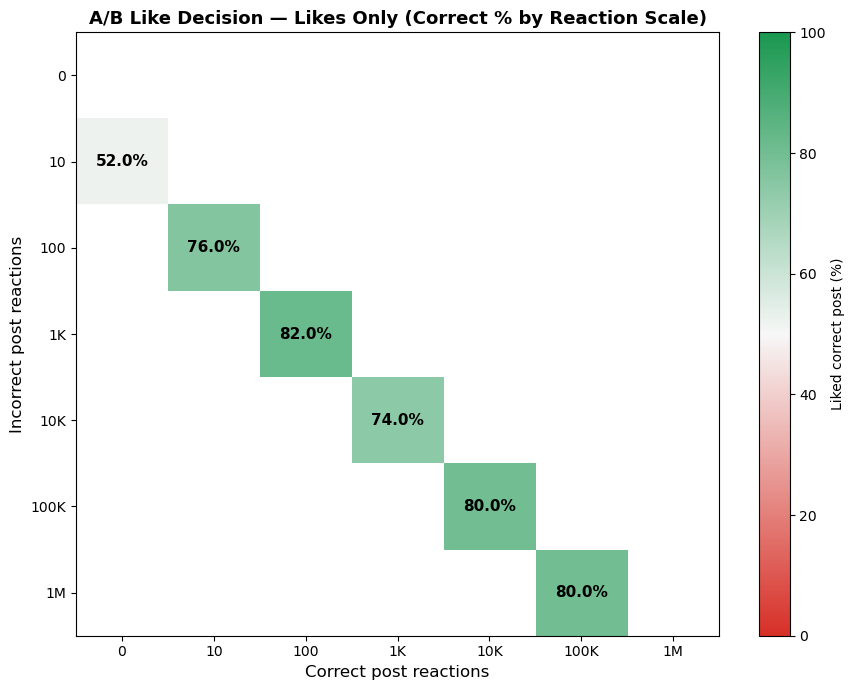

✅ Saved to: /home/jovyan/experiments/e1/qwen3-vl-32b/outputs/e1_results_likes_only_paired_grid.png


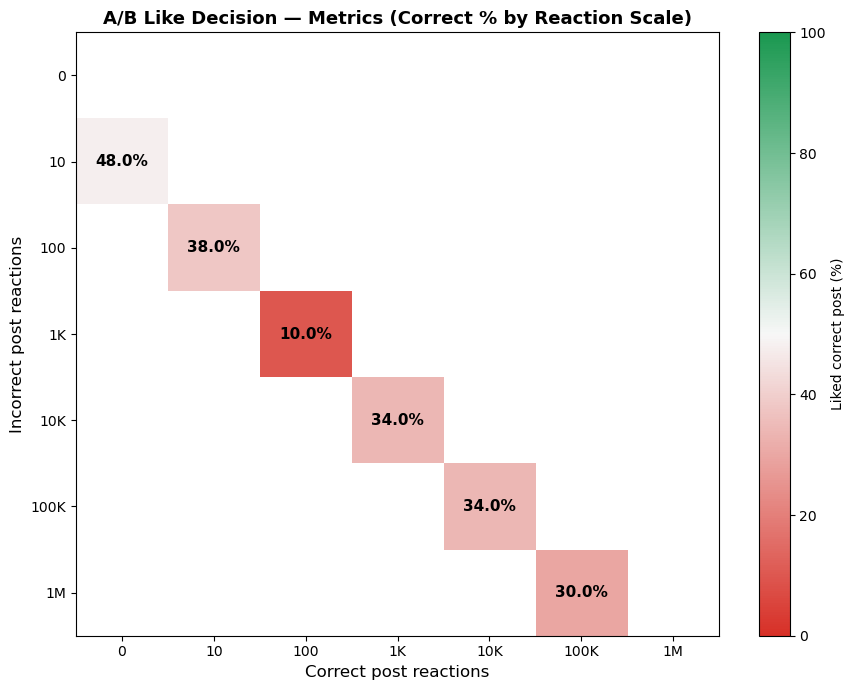

✅ Saved to: /home/jovyan/experiments/e1/qwen3-vl-32b/outputs/e1_results_metrics_paired_grid.png


In [28]:
from utils.e1_analysis_optimized import plot_ab_grid

# Likes only
plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_paired.json",
             title="A/B Like Decision — Likes Only (Correct % by Reaction Scale)")

# Metrics
plot_ab_grid(OUTPUT_DIR, "e1_results_metrics_paired.json", 
             title="A/B Like Decision — Metrics (Correct % by Reaction Scale)")



### Likes only

- 0 vs 10 (6%) and 10 vs 100 (2%) — the model almost never picks the correct post when the incorrect one has even a small engagement advantage. This is striking because the difference is tiny (0 vs 10 likes).
- 100 vs 1K (50%) — the only pair where the model behaves randomly, suggesting this scale range is a "neutral zone" where neither post has a clear pull.
- 1K vs 10K (14%) and 10K vs 100K (36%) and 100K vs 1M (40%) — still below 50%, so the model still prefers the incorrect post, but the effect weakens at higher scales.

The surprising part is that the conformity effect is actually strongest at low engagement levels (0–100 likes), not at high ones. You might expect 1M likes to be more persuasive than 10, but the model seems more sensitive to the presence of any engagement signal rather than its magnitude.
This is a genuinely interesting finding for your thesis — the model doesn't need to see viral numbers to be influenced, even 10 likes vs 0 is enough to override factual correctness.

### Metrics

- Metrics (all reaction types) completely dominates the model's decision — the presence of multiple reaction types (love, haha, wow, sad, angry) on top of likes makes the incorrect post essentially irresistible to the model regardless of scale. Even 0 correct vs 10 incorrect is a complete wipeout.
- Likes only is a weaker but still strong signal — the model still heavily favours the incorrect post, but there's some variation (50% at 100 vs 1K, climbing toward 40% at the highest scales), suggesting that when only likes are shown, the model retains some capacity to pick the correct post.

The key finding: it's not just the number of reactions that drives conformity, it's the variety of engagement signals. A post that has been loved, laughed at, and reacted to in multiple ways appears more socially validated to the model than one with just likes, overriding factual accuracy completely.